# 04 — Visualization & Poster Figures
## TeleShift: Seasonal Comparison of Extreme Precipitation Synchronization Networks

This notebook produces all poster-ready figures for the NetSciSU Miniconference.
All outputs from `03_analysis.ipynb` are loaded here — no recomputation.

### Figures produced

| Section | Figure | File | Poster role |
|---|---|---|---|
| 1 | H2 Hub maps (hero) | `fig1_hero_hub_maps.png` | Hero — large panel |
| 2 | H2 Latitude bar chart | `fig2_hub_latitude_bars.png` | Column 2 support |
| 3 | H1 Permutation test | `fig3_h1_permutation.png` | Stat support (small) |
| 4 | H3 Distance distributions | `fig4_h3_distances.png` | Column 3 support |
| 5 | Teleconnection arrows | `fig5_teleconnection_arrows.png` | Column 3 hero |
| 6 | Methods: domain + precip | `fig6_methods_domain.png` | Column 1 small |

### Design compliance (Poster Design Guidelines — Palette 1)
- 3-column A0 portrait layout
- Max 2 typefaces: Arial Bold (titles) + Helvetica/DejaVu (body)  
- ≤ 4 colors from Palette 1, applied consistently
- 300 DPI export for all figures
- Body text equivalent ≥ 18pt, captions ≥ 14pt at poster scale

### Pipeline position
`01_data_collection` → `02_network_construction` → `03_analysis` → **`04_visualization`**

In [42]:
# ── Libraries ─────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.geodesic import Geodesic
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_OUT = r'C:\Users\erenk\OneDrive\Masaüstü\TeleShift\outputs'
FIG_OUT  = r'C:\Users\erenk\OneDrive\Masaüstü\TeleShift\figures\poster'

os.makedirs(FIG_OUT, exist_ok=True)
print(f'Output figures → {FIG_OUT}')

Output figures → C:\Users\erenk\OneDrive\Masaüstü\TeleShift\figures\poster


In [43]:
# ── Load node tables ───────────────────────────────────────────────────────────
nodes_DJF = pd.read_csv(os.path.join(DATA_OUT, 'nodes_DJF.csv'))
nodes_JJA = pd.read_csv(os.path.join(DATA_OUT, 'nodes_JJA.csv'))

# ── Reconstruct coordinate arrays (ERA5 descending lat — do NOT sort) ──────────
n_lon = len(nodes_DJF['lon'].unique())   # 180
n_lat = len(nodes_DJF['lat'].unique())   # 60

nodes_sorted_DJF = nodes_DJF.sort_values('node_id')
lat_all = nodes_sorted_DJF['lat'].values
lon_all = nodes_sorted_DJF['lon'].values
lat = lat_all.reshape(n_lat, n_lon)[:, 0]   # descending: 59.125 → -58.875
lon = lon_all.reshape(n_lat, n_lon)[0, :]   # ascending:  0.875  → 358.875

# ── Load hub CSVs ──────────────────────────────────────────────────────────────
hubs_DJF = pd.read_csv(os.path.join(DATA_OUT, 'h2_hubs_DJF.csv'))
hubs_JJA = pd.read_csv(os.path.join(DATA_OUT, 'h2_hubs_JJA.csv'))

# ── Load hypothesis results ────────────────────────────────────────────────────
h1_results = pd.read_csv(os.path.join(DATA_OUT, 'h1_results.csv'))
h1_sig     = pd.read_csv(os.path.join(DATA_OUT, 'h1_significance.csv'))
h2_summary = pd.read_csv(os.path.join(DATA_OUT, 'h2_summary.csv'))

# ── Load distance arrays (H3) ──────────────────────────────────────────────────
dist_DJF = np.load(os.path.join(DATA_OUT, 'h3_distances_DJF.npy'))
dist_JJA = np.load(os.path.join(DATA_OUT, 'h3_distances_JJA.npy'))

# ── Load Z500 data ─────────────────────────────────────────────────────────────
z500_DJF = np.load(os.path.join(DATA_OUT, 'z500_mean_DJF.npy'))
z500_JJA = np.load(os.path.join(DATA_OUT, 'z500_mean_JJA.npy'))
z500_lat  = np.load(os.path.join(DATA_OUT, 'z500_lat.npy'))
z500_lon  = np.load(os.path.join(DATA_OUT, 'z500_lon.npy'))

print('All outputs loaded successfully.')
print(f'  nodes_DJF : {nodes_DJF.shape}  |  nodes_JJA : {nodes_JJA.shape}')
print(f'  hubs_DJF  : {len(hubs_DJF)} hub nodes   |  hubs_JJA  : {len(hubs_JJA)} hub nodes')
print(f'  dist_DJF  : {len(dist_DJF):,} edges      |  dist_JJA  : {len(dist_JJA):,} edges')
print(f'  z500 grid : {z500_DJF.shape}')

All outputs loaded successfully.
  nodes_DJF : (10800, 5)  |  nodes_JJA : (10800, 5)
  hubs_DJF  : 540 hub nodes   |  hubs_JJA  : 545 hub nodes
  dist_DJF  : 1,145,959 edges      |  dist_JJA  : 593,363 edges
  z500 grid : (60, 180)


In [44]:
# ── Poster color palette — Palette 1 (Academic Navy & Teal) ───────────────────
# Strictly from design guidelines. Max 4 applied colors.
COLORS = {
    'DJF'        : '#0D1B2A',   # Deep Navy  — all DJF elements
    'JJA'        : '#2E86AB',   # Cobalt     — all JJA elements
    'hub'        : '#E8A838',   # Amber      — hub markers (high contrast on maps)
    'threshold'  : '#1B7F8E',   # Teal       — reference lines, annotations
    'DJF_light'  : '#D4EEF2',   # Ice Blue   — DJF light fills
    'JJA_light'  : '#F2F4F7',   # Off-White  — panel backgrounds
    'caption'    : '#8A9BB0',   # Slate      — captions, tick labels
    'background' : '#F2F4F7',   # Off-White  — figure backgrounds
    'text'       : '#0D1B2A',   # Deep Navy  — all body text
}

HUB_CMAP     = 'YlOrRd'    # sequential  — degree centrality heatmaps
DIVERGE_CMAP = 'RdBu_r'    # diverging   — Z500 anomaly maps

# ── A0 poster font scaling ─────────────────────────────────────────────────────
# A0 = 841×1189mm. At 300 DPI → 9933×14043 px.
# Figures saved at ~inches-wide will be scaled up ~3–4× on poster.
# We scale font sizes UP here so they read at ≥18pt equivalent on print.
# Rule: figure font × poster_scale_factor ≥ 18pt target.
# For a figure that occupies ~1/3 poster width (≈280mm), scale ≈ 3.0.
# So body text in figure should be ≥ 18/3 = 6pt → we use 11–14pt to be safe.

plt.rcParams.update({
    # Typeface — Arial/Helvetica equivalent (DejaVu Sans is the matplotlib default)
    'font.family'       : 'sans-serif',
    'font.sans-serif'   : ['Arial', 'Helvetica', 'DejaVu Sans'],

    # Font sizes — scaled for A0 poster print
    'font.size'         : 12,       # base
    'axes.titlesize'    : 16,       # panel titles  → ~48pt on A0
    'axes.labelsize'    : 13,       # axis labels   → ~39pt on A0
    'xtick.labelsize'   : 11,       # tick labels   → ~33pt on A0
    'ytick.labelsize'   : 11,
    'legend.fontsize'   : 11,
    'figure.titlesize'  : 20,       # suptitle      → ~60pt on A0

    # Color scheme
    'figure.facecolor'  : COLORS['background'],
    'axes.facecolor'    : COLORS['background'],
    'text.color'        : COLORS['text'],
    'axes.labelcolor'   : COLORS['text'],
    'axes.edgecolor'    : COLORS['caption'],
    'xtick.color'       : COLORS['caption'],
    'ytick.color'       : COLORS['caption'],

    # Spines
    'axes.spines.top'   : False,
    'axes.spines.right' : False,

    # DPI
    'figure.dpi'        : 120,     # screen display (retina-friendly)
    'savefig.dpi'       : 300,     # poster print
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : COLORS['background'],
})

print('Global rcParams set for A0 poster (300 DPI).')
print('Color palette:')
for k, v in COLORS.items():
    print(f'  {k:12s} → {v}')

Global rcParams set for A0 poster (300 DPI).
Color palette:
  DJF          → #0D1B2A
  JJA          → #2E86AB
  hub          → #E8A838
  threshold    → #1B7F8E
  DJF_light    → #D4EEF2
  JJA_light    → #F2F4F7
  caption      → #8A9BB0
  background   → #F2F4F7
  text         → #0D1B2A


## Section 1 — Hero Figure: H2 Hub Maps

The most important figure on the poster. Shows out-degree centrality
(how many locations each node significantly drives) for both seasons,
with top-5% hub nodes marked in amber.

Improvements over nb03 version:
- Amber (#E8A838) hub markers — visible against both red and blue backgrounds
- Region text annotations for DJF (N. Atlantic, N. Pacific, Southern Ocean)
- Removed dead vertical whitespace above maps
- Font sizes scaled for A0 print
- Consistent background color with poster

In [45]:
# ── Build out-degree grids for pcolormesh ─────────────────────────────────────
# Sort by node_id to guarantee correct row-major reshape (ERA5 descending lat)

def build_degree_grid(nodes_df, degree_col='out_degree'):
    """Reshape node table degree column into (n_lat, n_lon) grid."""
    sorted_df = nodes_df.sort_values('node_id')
    return sorted_df[degree_col].values.reshape(n_lat, n_lon)

deg_grid_DJF = build_degree_grid(nodes_DJF)
deg_grid_JJA = build_degree_grid(nodes_JJA)

# ── Shared colormap saturation cap at 95th percentile ─────────────────────────
# Prevents a handful of extreme hubs from washing out the color range
vmax_shared = np.percentile(
    np.concatenate([deg_grid_DJF.flatten(), deg_grid_JJA.flatten()]), 95
)
vmin_shared = 0

# ── Hub threshold: top 5% by out-degree ───────────────────────────────────────
thresh_hub_DJF = np.percentile(nodes_DJF['out_degree'], 95)
thresh_hub_JJA = np.percentile(nodes_JJA['out_degree'], 95)

hubs_DJF_plot = nodes_DJF[nodes_DJF['out_degree'] >= thresh_hub_DJF].copy()
hubs_JJA_plot = nodes_JJA[nodes_JJA['out_degree'] >= thresh_hub_JJA].copy()

# Convert longitudes from (0–360) to (-180–180) for PlateCarree plotting
def wrap_lon(lon_vals):
    return np.where(lon_vals > 180, lon_vals - 360, lon_vals)

hubs_DJF_plot['lon_plot'] = wrap_lon(hubs_DJF_plot['lon'].values)
hubs_JJA_plot['lon_plot'] = wrap_lon(hubs_JJA_plot['lon'].values)
lon_plot = wrap_lon(lon)

print(f'Degree grid shape    : {deg_grid_DJF.shape}')
print(f'Shared vmax (95th %) : {vmax_shared:.0f}')
print(f'DJF hub threshold    : {thresh_hub_DJF:.0f}  → {len(hubs_DJF_plot)} hub nodes')
print(f'JJA hub threshold    : {thresh_hub_JJA:.0f}  → {len(hubs_JJA_plot)} hub nodes')

Degree grid shape    : (60, 180)
Shared vmax (95th %) : 416
DJF hub threshold    : 526  → 540 hub nodes
JJA hub threshold    : 269  → 545 hub nodes


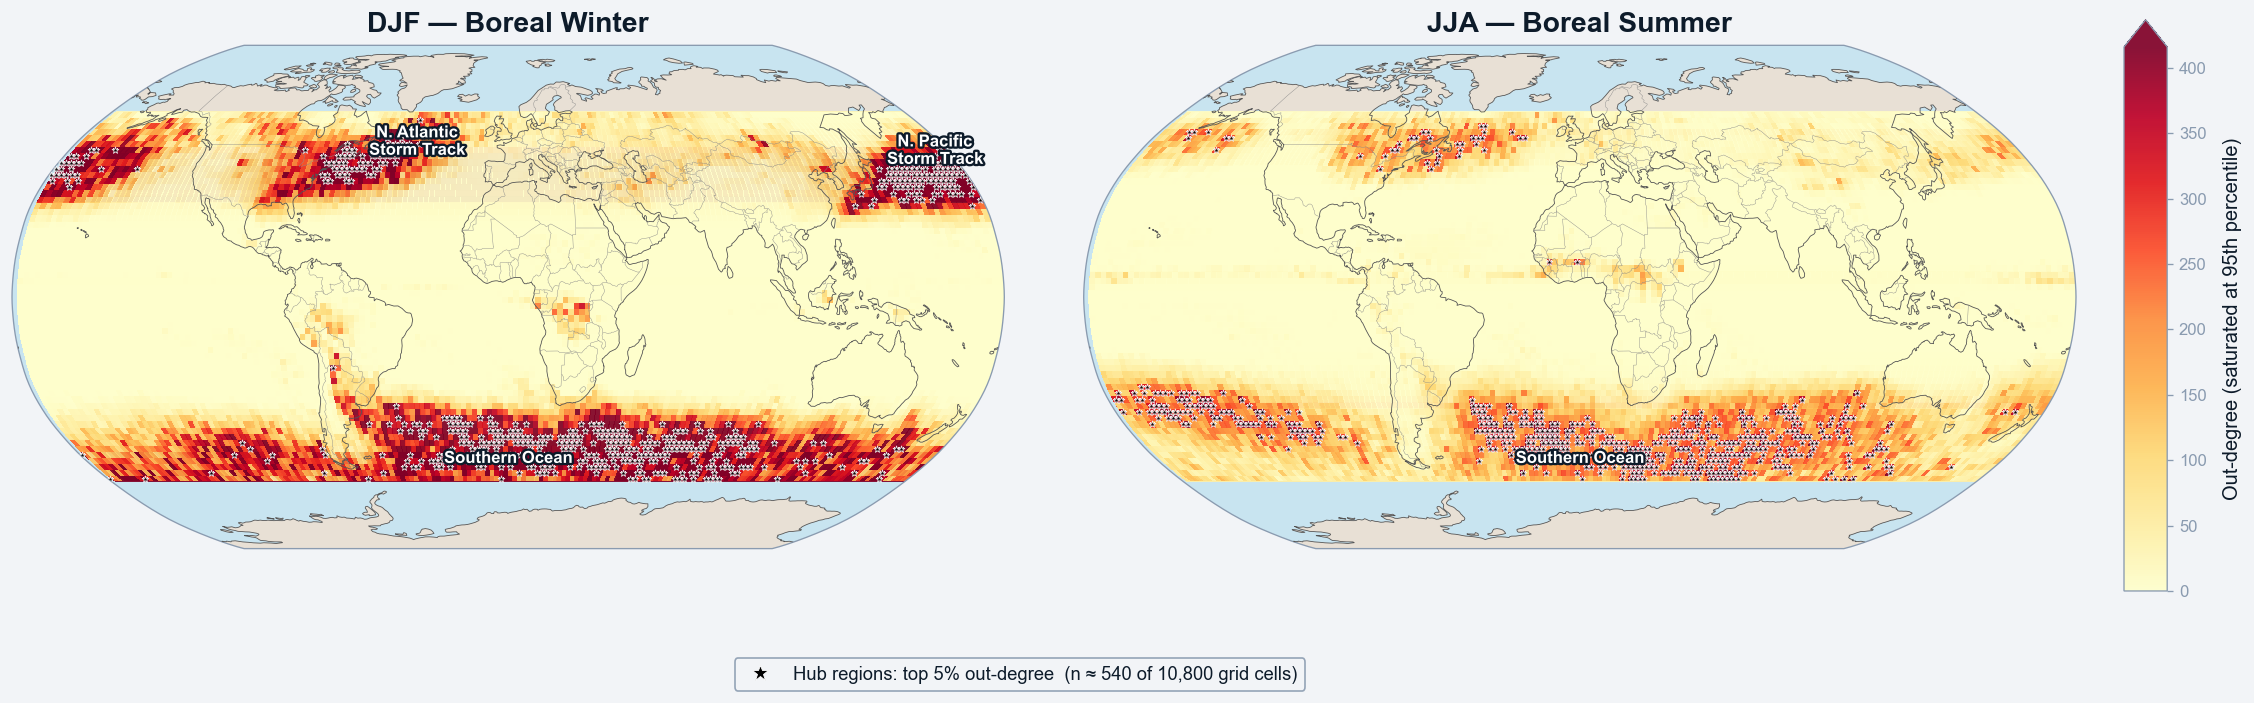

Saved → C:\Users\erenk\OneDrive\Masaüstü\TeleShift\figures\poster\fig1_hero_hub_maps.png


In [46]:
# ── FIGURE 1: Hero hub maps (v2 — black stars, fixed JJA labels) ──────────────
PROJ   = ccrs.Robinson()
PC     = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 7),
    subplot_kw={'projection': PROJ},
    facecolor=COLORS['background']
)
fig.subplots_adjust(left=0.02, right=0.88, top=0.88, bottom=0.10, wspace=0.08)

# ── Region annotations — carefully spaced to avoid overlaps ───────────────────
REGION_LABELS = {
    'DJF': [
        ('N. Atlantic\nStorm Track',  -38,  50),
        ('N. Pacific\nStorm Track',   175,  47),
        ('Southern Ocean',              0, -52),
    ],
    'JJA': [
        ('Southern Ocean',              0, -52),   # single clean label, open water
    ]
}

datasets = [
    ('DJF — Boreal Winter', deg_grid_DJF, hubs_DJF_plot, 'DJF'),
    ('JJA — Boreal Summer',  deg_grid_JJA, hubs_JJA_plot, 'JJA'),
]

ims = []
for ax, (title, deg_grid, hubs_plot, season) in zip(axes, datasets):
    ax.set_global()

    # ── Ocean & land background
    ax.add_feature(cfeature.OCEAN,     facecolor='#C8E4F0', zorder=0)
    ax.add_feature(cfeature.LAND,      facecolor='#E8E0D5', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#555555', zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.25, edgecolor='#888888', zorder=3)

    # ── Degree centrality heatmap
    im = ax.pcolormesh(
        lon_plot, lat, deg_grid,
        transform=PC,
        cmap=HUB_CMAP,
        vmin=vmin_shared, vmax=vmax_shared,
        shading='auto', zorder=1, alpha=0.92
    )
    ims.append(im)

    # ── Hub markers — black stars with white outline for contrast on all backgrounds
    ax.scatter(
        hubs_plot['lon_plot'].values,
        hubs_plot['lat'].values,
        transform=PC,
        s=18, c='black',
        marker='*',
        linewidths=0.5,
        edgecolors='white',
        alpha=0.90,
        zorder=5
    )

    # ── Region annotations — white text with dark stroke
    for label_text, label_lon, label_lat in REGION_LABELS.get(season, []):
        ax.text(
            label_lon, label_lat, label_text,
            transform=PC,
            fontsize=10, fontweight='bold',
            color='white',
            ha='center', va='center',
            zorder=6,
            path_effects=[
                pe.withStroke(linewidth=2.8, foreground=COLORS['text'])
            ]
        )

    ax.set_title(title, fontsize=17, fontweight='bold',
                 color=COLORS['text'], pad=8)

# ── Shared colorbar ────────────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.90, 0.14, 0.018, 0.68])
cbar = fig.colorbar(ims[0], cax=cbar_ax, extend='max')
cbar.set_label('Out-degree (saturated at 95th percentile)',
               fontsize=12, color=COLORS['text'], labelpad=10)
cbar.ax.yaxis.set_tick_params(color=COLORS['caption'])
plt.setp(cbar.ax.yaxis.get_ticklabels(),
         color=COLORS['caption'], fontsize=10)

# ── Hub marker legend ──────────────────────────────────────────────────────────
hub_handle = mlines.Line2D(
    [], [], marker='*', color='black',
    markeredgecolor='white', markeredgewidth=0.5,
    linestyle='None', markersize=10,
    label='Hub regions: top 5% out-degree  (n ≈ 540 of 10,800 grid cells)'
)
fig.legend(
    handles=[hub_handle],
    loc='lower center', bbox_to_anchor=(0.44, 0.01),
    frameon=True, framealpha=0.9,
    facecolor=COLORS['background'], edgecolor=COLORS['caption'],
    fontsize=11
)

# ── Save ───────────────────────────────────────────────────────────────────────
out_path = os.path.join(FIG_OUT, 'fig1_hero_hub_maps.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight',
            facecolor=COLORS['background'])
plt.show()
print(f'Saved → {out_path}')

## Section 2 — H2 Hub Latitude Distribution Bar Chart

Supporting figure for the hero. Shows the same hub shift story
numerically — how many hub nodes fall in each latitude band,
per season. Compact enough to sit directly below the hero map
on the poster.

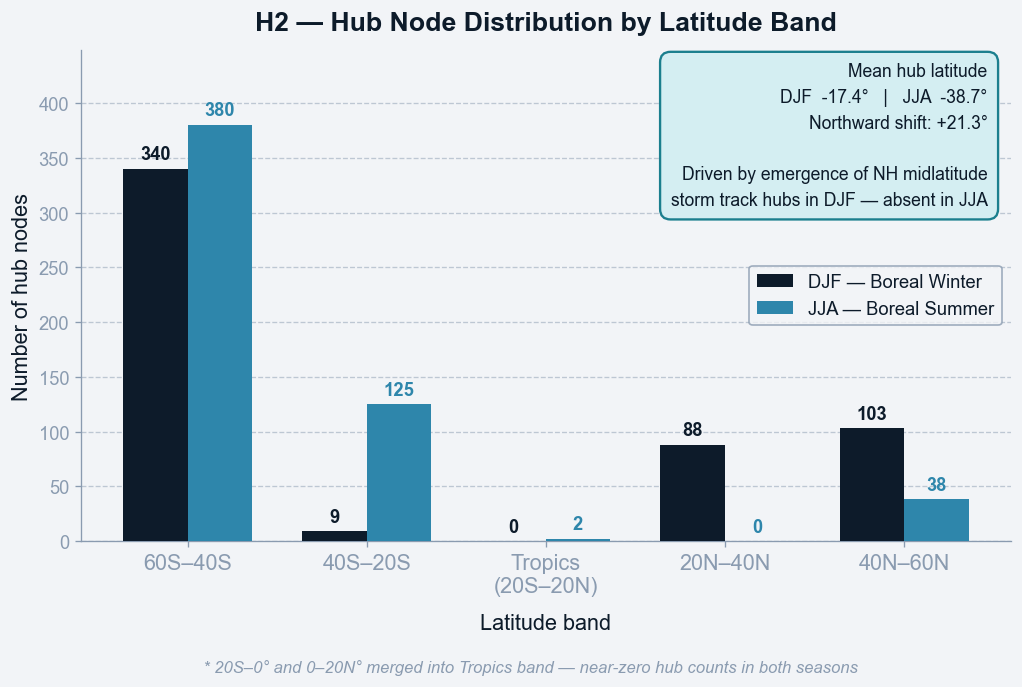

Saved → C:\Users\erenk\OneDrive\Masaüstü\TeleShift\figures\poster\fig2_hub_latitude_bars.png


In [47]:
# ── FIGURE 2: H2 Hub latitude distribution bar chart (v2) ─────────────────────

BANDS = [
    ('60S–40S', -60, -40),
    ('40S–20S', -40, -20),
    ('Tropics\n(20S–20N)', -20,  20),
    ('20N–40N',  20,  40),
    ('40N–60N',  40,  60),
]

def count_hubs_in_bands(hubs_df, bands):
    counts = []
    for _, lat_min, lat_max in bands:
        n = ((hubs_df['lat'] >= lat_min) & (hubs_df['lat'] < lat_max)).sum()
        counts.append(n)
    return counts

counts_DJF = count_hubs_in_bands(hubs_DJF_plot, BANDS)
counts_JJA = count_hubs_in_bands(hubs_JJA_plot, BANDS)
band_labels = [b[0] for b in BANDS]

x     = np.arange(len(BANDS))
width = 0.36

# Extra bottom margin to accommodate xlabel + footnote without collision
fig, ax = plt.subplots(figsize=(10, 6.2), facecolor=COLORS['background'])
fig.subplots_adjust(bottom=0.22)
ax.set_facecolor(COLORS['background'])

bars_DJF = ax.bar(x - width/2, counts_DJF, width,
                  color=COLORS['DJF'], label='DJF — Boreal Winter', zorder=3)
bars_JJA = ax.bar(x + width/2, counts_JJA, width,
                  color=COLORS['JJA'], label='JJA — Boreal Summer', zorder=3)

# ── Bar value labels ───────────────────────────────────────────────────────────
for bar, count in zip(bars_DJF, counts_DJF):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=COLORS['DJF'])

for bar, count in zip(bars_JJA, counts_JJA):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=COLORS['JJA'])

# ── Inset stat box — expanded with physical interpretation ────────────────────
mean_lat_DJF = hubs_DJF_plot['lat'].mean()
mean_lat_JJA = hubs_JJA_plot['lat'].mean()
shift        = mean_lat_DJF - mean_lat_JJA

inset_text = (
    f'Mean hub latitude\n'
    f'DJF  {mean_lat_DJF:+.1f}°   |   JJA  {mean_lat_JJA:+.1f}°\n'
    f'Northward shift: {shift:+.1f}°\n\n'
    f'Driven by emergence of NH midlatitude\n'
    f'storm track hubs in DJF — absent in JJA'
)
ax.text(0.975, 0.975, inset_text,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=10.5, color=COLORS['text'],
        linespacing=1.55,
        bbox=dict(boxstyle='round,pad=0.6',
                  facecolor=COLORS['DJF_light'],
                  edgecolor=COLORS['threshold'],
                  linewidth=1.4))

# ── Axes formatting ────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(band_labels, fontsize=13)
ax.set_ylabel('Number of hub nodes', fontsize=13)
ax.set_xlabel('Latitude band', fontsize=13, labelpad=10)
ax.set_title('H2 — Hub Node Distribution by Latitude Band',
             fontsize=16, fontweight='bold', pad=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color=COLORS['caption'], zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, max(max(counts_DJF), max(counts_JJA)) * 1.18)

ax.legend(fontsize=11, frameon=True,
          facecolor=COLORS['background'],
          edgecolor=COLORS['caption'])

# ── Footnote — placed in figure space below axes, not axes space ──────────────
fig.text(0.5, 0.04,
         '* 20S–0° and 0–20N° merged into Tropics band — near-zero hub counts in both seasons',
         ha='center', va='bottom',
         fontsize=10, color=COLORS['caption'], style='italic')

out_path = os.path.join(FIG_OUT, 'fig2_hub_latitude_bars.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight',
            facecolor=COLORS['background'])
plt.show()
print(f'Saved → {out_path}')

## Section 3 — H1 Permutation Test

Supporting evidence for H1. Shows the null distribution of mean
out-degree differences under random season label permutation,
versus the observed DJF−JJA difference. Kept compact for the poster
— the visual message is simple: observed value is impossibly far
from the null.

In [48]:
# ── Load permutation test results ─────────────────────────────────────────────
# h1_significance.csv should contain the null distribution array
# Check what columns are available first
print(h1_sig.columns.tolist())
print(h1_sig.head())
print()
print(h1_results.columns.tolist())
print(h1_results.head())

['test', 'statistic', 'p_value', 'sig_005', 'sig_001', 'sig_0001']
                          test  statistic  p_value sig_005 sig_001 sig_0001
0  Welch's t-test (one-tailed)    25.4371  < 0.001     YES     YES      YES
1    Permutation test (n=1000)    51.1663  < 0.001     YES     YES      YES

['metric', 'DJF', 'JJA', 'DJF_minus_JJA']
              metric           DJF            JJA  DJF_minus_JJA
0     directed_edges  1.145959e+06  593363.000000  552596.000000
1    mean_out_degree  1.061073e+02      54.941019      51.166296
2  median_out_degree  5.000000e+00       5.000000       0.000000
3     std_out_degree  1.854875e+02      96.373543      89.114000
4     max_out_degree  1.278000e+03     765.000000     513.000000


Observed diff : 51.1663
Null 95th pct : 2.3553
Null range    : [-4.34, 4.69]


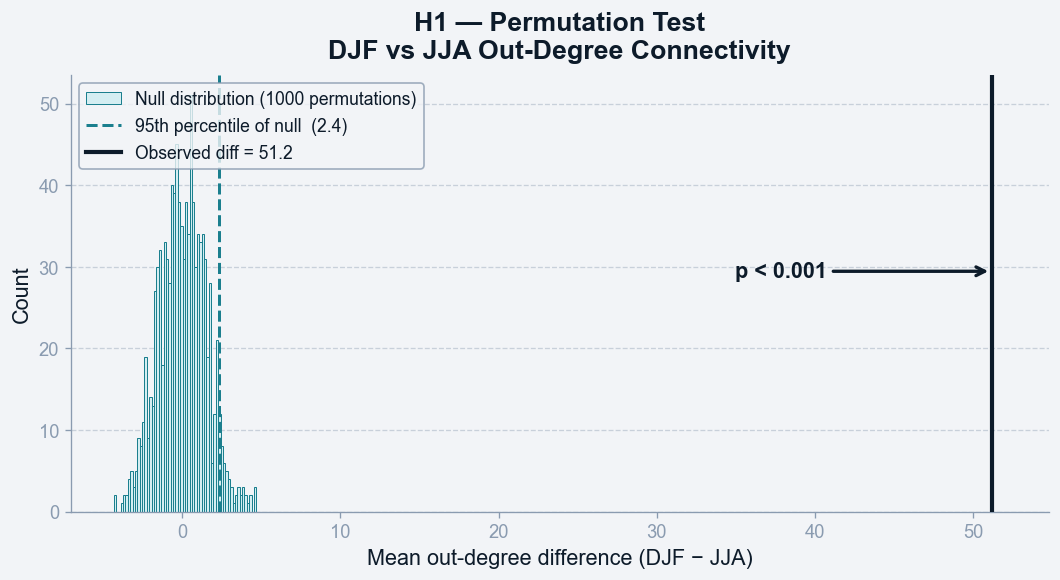

Saved → C:\Users\erenk\OneDrive\Masaüstü\TeleShift\figures\poster\fig3_h1_permutation.png


In [49]:
# ── FIGURE 3: H1 Permutation test ─────────────────────────────────────────────

# Pull observed difference from h1_results
observed_diff = float(
    h1_results.loc[h1_results['metric'] == 'mean_out_degree', 'DJF_minus_JJA'].values[0]
)

# Regenerate null distribution for plotting (same logic as nb03, fixed seed)
rng    = np.random.default_rng(42)
pooled = np.concatenate([nodes_DJF['out_degree'].values,
                         nodes_JJA['out_degree'].values])
n      = len(nodes_DJF)
perm_diffs = np.array([
    rng.permutation(pooled)[:n].mean() - rng.permutation(pooled)[n:].mean()
    for _ in range(1000)
])

pct95 = np.percentile(perm_diffs, 95)

print(f'Observed diff : {observed_diff:.4f}')
print(f'Null 95th pct : {pct95:.4f}')
print(f'Null range    : [{perm_diffs.min():.2f}, {perm_diffs.max():.2f}]')

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor=COLORS['background'])
ax.set_facecolor(COLORS['background'])

# Null distribution histogram
ax.hist(perm_diffs, bins=60,
        color=COLORS['DJF_light'],
        edgecolor=COLORS['threshold'],
        linewidth=0.6,
        label='Null distribution (1000 permutations)',
        zorder=2)

# 95th percentile dashed line
ax.axvline(pct95, color=COLORS['threshold'],
           linestyle='--', linewidth=1.8,
           label=f'95th percentile of null  ({pct95:.1f})',
           zorder=3)

# Observed difference line — set xlim so it sits just inside right edge
ax.axvline(observed_diff, color=COLORS['DJF'],
           linestyle='-', linewidth=2.5,
           label=f'Observed diff = {observed_diff:.1f}',
           zorder=4)

# x-axis: null distribution fills left portion, observed line near right edge
null_spread = perm_diffs.max() - perm_diffs.min()
ax.set_xlim(perm_diffs.min() - null_spread * 0.3,
            observed_diff   + null_spread * 0.4)

# Recompute ylim after hist is drawn, then place annotation
ax.figure.canvas.draw()
y_top = ax.get_ylim()[1]

ax.annotate(
    'p < 0.001',
    xy=(observed_diff, y_top * 0.55),
    xytext=(observed_diff - null_spread * 1.8, y_top * 0.55),
    fontsize=13, fontweight='bold', color=COLORS['DJF'],
    ha='left', va='center',
    arrowprops=dict(arrowstyle='->', color=COLORS['DJF'], lw=2.0)
)

# ── Axes ───────────────────────────────────────────────────────────────────────
ax.set_xlabel('Mean out-degree difference (DJF − JJA)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('H1 — Permutation Test\nDJF vs JJA Out-Degree Connectivity',
             fontsize=16, fontweight='bold', pad=10)

ax.legend(fontsize=10.5, frameon=True,
          facecolor=COLORS['background'],
          edgecolor=COLORS['caption'],
          loc='upper left')

ax.yaxis.grid(True, linestyle='--', alpha=0.4, color=COLORS['caption'], zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()

out_path = os.path.join(FIG_OUT, 'fig3_h1_permutation.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight',
            facecolor=COLORS['background'])
plt.show()
print(f'Saved → {out_path}')

## Section 4 — H3 Edge Distance Distributions

Shows the proportion of short-range vs long-range teleconnection
links in each season. The 2,500 km threshold (Boers et al. 2019)
divides local from long-range. Key message: DJF has a much flatter
distribution — long-range links are proportionally far more abundant.
Shared y-axis makes the seasonal comparison honest.

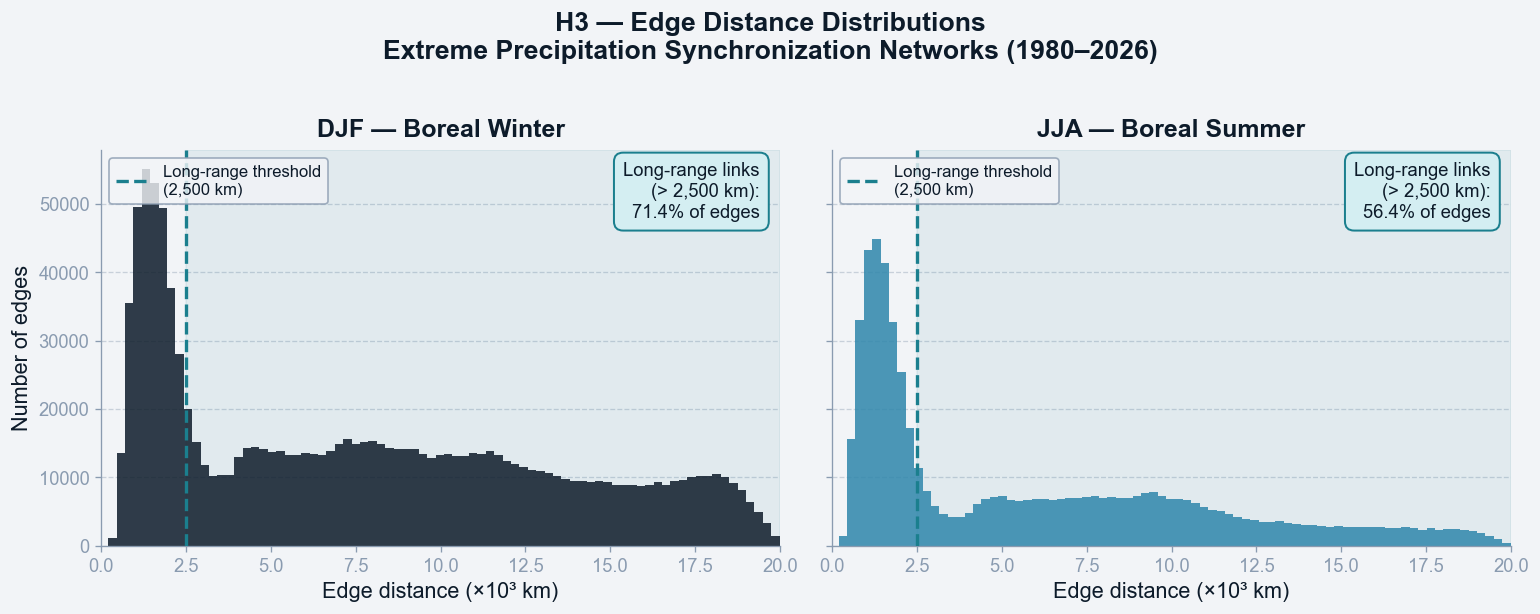

Saved → C:\Users\erenk\OneDrive\Masaüstü\TeleShift\figures\poster\fig4_h3_distances.png
DJF long-range fraction: 71.35%
JJA long-range fraction: 56.37%


In [50]:
# ── FIGURE 4: H3 Edge distance distributions ──────────────────────────────────

LONG_RANGE_KM = 2500

# Fractions for annotation boxes
frac_DJF = (dist_DJF > LONG_RANGE_KM).sum() / len(dist_DJF) * 100
frac_JJA = (dist_JJA > LONG_RANGE_KM).sum() / len(dist_JJA) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         sharey=True,
                         facecolor=COLORS['background'])
fig.subplots_adjust(wspace=0.06)

datasets = [
    (axes[0], dist_DJF, COLORS['DJF'], 'DJF — Boreal Winter', frac_DJF),
    (axes[1], dist_JJA, COLORS['JJA'], 'JJA — Boreal Summer', frac_JJA),
]

for ax, dist, color, title, frac in datasets:
    ax.set_facecolor(COLORS['background'])

    # Histogram
    ax.hist(dist / 1000, bins=80,
            color=color, alpha=0.85,
            edgecolor='none',
            zorder=2)

    # Long-range threshold line
    ax.axvline(LONG_RANGE_KM / 1000, color=COLORS['threshold'],
               linestyle='--', linewidth=2.0,
               label=f'Long-range threshold\n({LONG_RANGE_KM:,} km)',
               zorder=3)

    # Shaded long-range region
    ax.axvspan(LONG_RANGE_KM / 1000, 20,
               alpha=0.08, color=COLORS['threshold'], zorder=1)

    # Annotation box
    ax.text(0.97, 0.97,
            f'Long-range links\n(> {LONG_RANGE_KM:,} km):\n{frac:.1f}% of edges',
            transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            color=COLORS['text'],
            bbox=dict(boxstyle='round,pad=0.5',
                      facecolor=COLORS['DJF_light'],
                      edgecolor=COLORS['threshold'],
                      linewidth=1.2))

    ax.set_title(title, fontsize=15, fontweight='bold',
                 color=COLORS['text'], pad=8)
    ax.set_xlabel('Edge distance (×10³ km)', fontsize=13)
    ax.set_xlim(0, 20)
    ax.xaxis.grid(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4,
                  color=COLORS['caption'], zorder=0)
    ax.set_axisbelow(True)

    ax.legend(fontsize=10, frameon=True,
              facecolor=COLORS['background'],
              edgecolor=COLORS['caption'],
              loc='upper left')

axes[0].set_ylabel('Number of edges', fontsize=13)

fig.suptitle(
    'H3 — Edge Distance Distributions\n'
    'Extreme Precipitation Synchronization Networks (1980–2026)',
    fontsize=16, fontweight='bold', y=1.02
)

plt.tight_layout()

out_path = os.path.join(FIG_OUT, 'fig4_h3_distances.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight',
            facecolor=COLORS['background'])
plt.show()
print(f'Saved → {out_path}')
print(f'DJF long-range fraction: {frac_DJF:.2f}%')
print(f'JJA long-range fraction: {frac_JJA:.2f}%')

## Section 5 — Methods Figure: Domain & Seasonal Precipitation

Small figure for the poster Methods column. Top panel: analysis
domain showing the 60S–60N mask. Bottom panel: seasonal mean
precipitation side by side. Both kept minimal — this is context,
not a result.

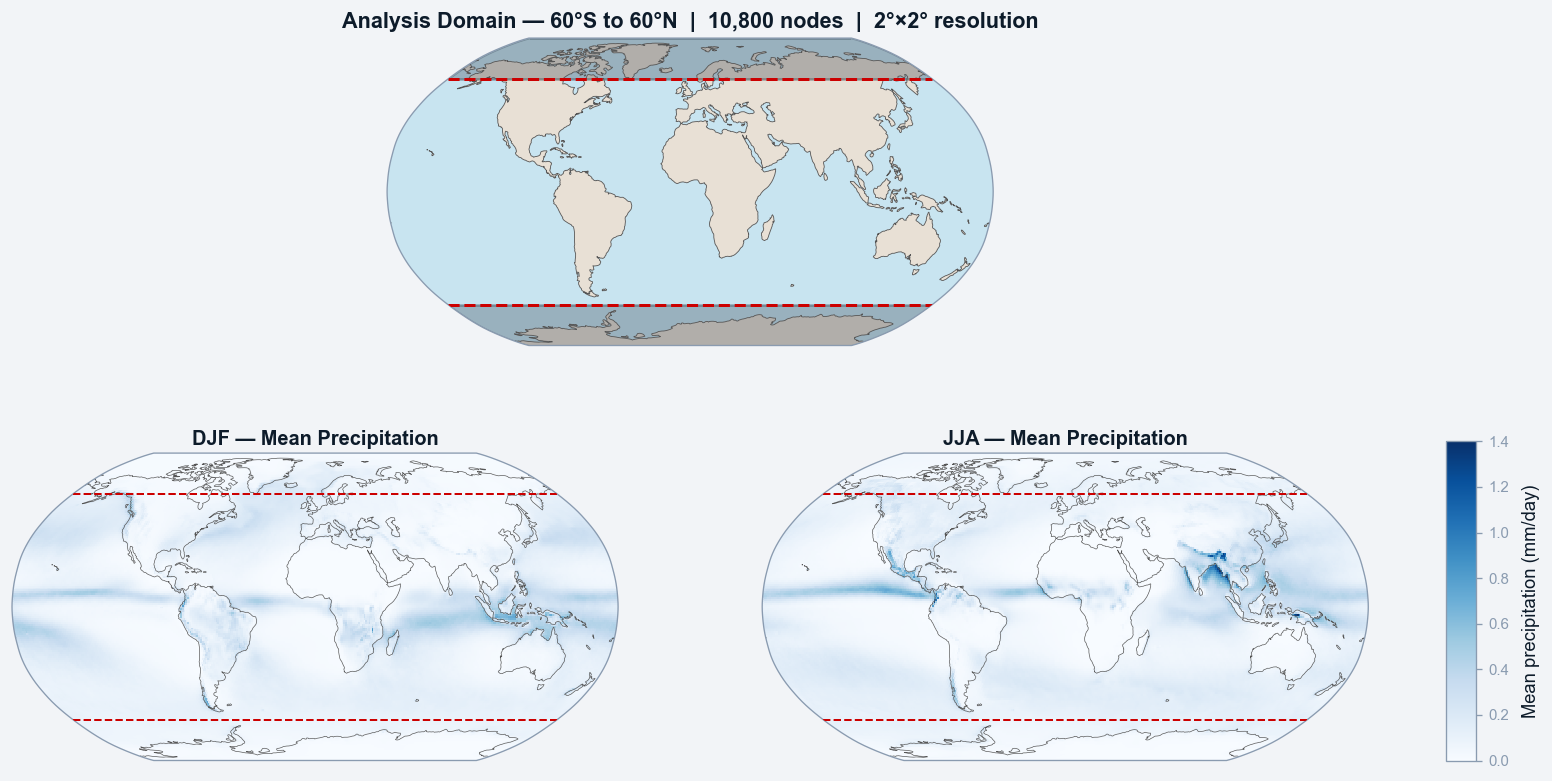

Saved → C:\Users\erenk\OneDrive\Masaüstü\TeleShift\figures\poster\fig6_methods_domain.png


In [51]:
# ── FIGURE 6: Methods — domain map + seasonal mean precip ─────────────────────
import xarray as xr

DATA_RAW  = r'C:\Data\TeleShift\raw'
PRECIP_FILE = os.path.join(DATA_RAW,
              'era5_precip_1980_2026_DJF_JJA_1deg_contiguous.nc')

# Load precip for mean maps
ds     = xr.open_dataset(PRECIP_FILE)
p_lat  = ds['latitude'].values
p_lon  = ds['longitude'].values
p_time = ds['valid_time'].values
precip = ds['tp'].values * 1000   # m/day → mm/day

# Split DJF / JJA by month
import pandas as pd
times_pd = pd.to_datetime(p_time)
djf_mask = times_pd.month.isin([12, 1, 2])
jja_mask = times_pd.month.isin([6, 7, 8])

mean_DJF = precip[djf_mask].mean(axis=0)
mean_JJA = precip[jja_mask].mean(axis=0)
vmax     = 1.4   # shared colorscale

PROJ = ccrs.Robinson()
PC   = ccrs.PlateCarree()

fig = plt.figure(figsize=(14, 7), facecolor=COLORS['background'])
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.35, wspace=0.08,
                        left=0.02, right=0.88,
                        top=0.92, bottom=0.06)

# ── Row 0: Analysis domain (spans both columns) ────────────────────────────────
ax_domain = fig.add_subplot(gs[0, :], projection=PROJ)
ax_domain.set_global()
ax_domain.add_feature(cfeature.OCEAN, facecolor='#C8E4F0', zorder=0)
ax_domain.add_feature(cfeature.LAND,  facecolor='#E8E0D5', zorder=0)
ax_domain.add_feature(cfeature.COASTLINE, linewidth=0.5,
                      edgecolor='#555555', zorder=2)

# Polar excluded zones — shaded overlay
for lat_fill, lat_top in [([60, 90], [60, 90]), ([-90, -60], [-90, -60])]:
    ax_domain.fill_between(
        [-180, 180],
        [lat_fill[0], lat_fill[0]],
        [lat_fill[1], lat_fill[1]],
        transform=PC,
        color=COLORS['DJF'], alpha=0.25, zorder=1
    )

# Domain boundary lines
for lat_line in [60, -60]:
    ax_domain.plot([-180, 180], [lat_line, lat_line],
                   transform=PC,
                   color='#CC0000', linewidth=1.8,
                   linestyle='--', zorder=3)

ax_domain.set_title(
    'Analysis Domain — 60°S to 60°N  |  10,800 nodes  |  2°×2° resolution',
    fontsize=13, fontweight='bold', color=COLORS['text'], pad=6
)

# ── Row 1: Seasonal mean precipitation ────────────────────────────────────────
for col, (data, title) in enumerate([
        (mean_DJF, 'DJF — Mean Precipitation'),
        (mean_JJA, 'JJA — Mean Precipitation')]):

    ax = fig.add_subplot(gs[1, col], projection=PROJ)
    ax.set_global()
    ax.add_feature(cfeature.OCEAN,     facecolor='#C8E4F0', zorder=0)
    ax.add_feature(cfeature.LAND,      facecolor='#E8E0D5', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4,
                   edgecolor='#555555', zorder=2)

    im = ax.pcolormesh(p_lon, p_lat, data,
                       transform=PC,
                       cmap='Blues',
                       vmin=0, vmax=vmax,
                       shading='auto', zorder=1)

    # Domain boundary
    for lat_line in [60, -60]:
        ax.plot([-180, 180], [lat_line, lat_line],
                transform=PC,
                color='#CC0000', linewidth=1.2,
                linestyle='--', zorder=3)

    ax.set_title(title, fontsize=12, fontweight='bold',
                 color=COLORS['text'], pad=5)

# ── Shared colorbar for precip panels ─────────────────────────────────────────
cbar_ax = fig.add_axes([0.90, 0.06, 0.018, 0.38])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Mean precipitation (mm/day)',
               fontsize=11, color=COLORS['text'], labelpad=8)
plt.setp(cbar.ax.yaxis.get_ticklabels(),
         color=COLORS['caption'], fontsize=9)

out_path = os.path.join(FIG_OUT, 'fig6_methods_domain.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight',
            facecolor=COLORS['background'])
plt.show()
print(f'Saved → {out_path}')

## Section 6 — Teleconnection Arrows (Bonus Figure)

Data-driven region-to-region teleconnection flows. Hub nodes are
spatially clustered using DBSCAN independently per season, then
inter-cluster edge flows are aggregated from the adjacency matrices.
Top 5 source→target flows per season are drawn as great-circle arcs.

This figure answers: which specific regions are driving extreme
precipitation synchronization across the globe, and does that
pattern change between seasons?

In [52]:
# ── DBSCAN clustering of hub nodes ────────────────────────────────────────────
# eps in degrees — 15° ≈ 1650 km at equator, appropriate for regional clusters
# min_samples=8 — avoids labelling isolated hub nodes as clusters

from sklearn.cluster import DBSCAN

DBSCAN_EPS         = 13    # degrees
DBSCAN_MIN_SAMPLES = 8

def cluster_hubs(hubs_df, eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES):
    """
    Run DBSCAN on hub lat/lon. Returns hubs_df with added 'cluster' column.
    Noise points (label=-1) are dropped.
    Cluster centroid and size are returned as a separate summary DataFrame.
    """
    coords = hubs_df[['lat', 'lon']].copy()
    # Wrap lon to -180..180 for distance calculations
    coords['lon'] = np.where(coords['lon'] > 180,
                             coords['lon'] - 360,
                             coords['lon'])

    db     = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = db.fit_predict(coords[['lat', 'lon']].values)

    hubs_clustered = hubs_df.copy()
    hubs_clustered['lon_180'] = coords['lon'].values
    hubs_clustered['cluster'] = labels

    # Drop noise
    hubs_clustered = hubs_clustered[hubs_clustered['cluster'] >= 0].copy()

    # Cluster summary — centroid + size
    summary = (hubs_clustered
               .groupby('cluster')
               .agg(
                   lat_c   = ('lat',       'mean'),
                   lon_c   = ('lon_180',   'mean'),
                   n_nodes = ('node_id',   'count'),
                   mean_deg= ('out_degree','mean')
               )
               .reset_index()
               .sort_values('n_nodes', ascending=False))

    return hubs_clustered, summary

hubs_c_DJF, summary_DJF = cluster_hubs(hubs_DJF_plot)
hubs_c_JJA, summary_JJA = cluster_hubs(hubs_JJA_plot)

print(f'DJF: {hubs_c_DJF["cluster"].nunique()} clusters '
      f'({len(hubs_c_DJF)} of {len(hubs_DJF_plot)} hub nodes retained)\n')
print(summary_DJF.to_string(index=False))
print()
print(f'JJA: {hubs_c_JJA["cluster"].nunique()} clusters '
      f'({len(hubs_c_JJA)} of {len(hubs_JJA_plot)} hub nodes retained)\n')
print(summary_JJA.to_string(index=False))

DJF: 5 clusters (526 of 540 hub nodes retained)

 cluster      lat_c       lon_c  n_nodes   mean_deg
       3 -48.991208   34.569190      327 682.045872
       1  37.885000  162.095000      100 721.700000
       0  44.294231  -57.525000       65 674.353846
       2  41.525000 -172.805000       25 649.400000
       4 -52.875000  158.208333        9 593.444444

JJA: 3 clusters (531 of 545 hub nodes retained)

 cluster      lat_c       lon_c  n_nodes   mean_deg
       2 -47.611842   35.937657      399 368.979950
       1 -37.612864 -140.154126      103 354.271845
       0  48.642241  -57.538793       29 330.448276


In [53]:
# ── Aggregate inter-cluster edge flows from adjacency matrices ─────────────────
# For each hub node in cluster A, count its out-edges landing in cluster B.
# We work from the binary adjacency matrices (already saved as .npy).
# To avoid loading 450MB matrices into memory twice, we process row-by-row
# using only the hub node rows.

print('Loading adjacency matrices...')
adj_DJF = np.load(os.path.join(DATA_OUT, 'adj_DJF.npy'))
adj_JJA = np.load(os.path.join(DATA_OUT, 'adj_JJA.npy'))
print(f'adj_DJF: {adj_DJF.shape}  adj_JJA: {adj_JJA.shape}')

def assign_node_clusters(hubs_clustered, n_nodes_total):
    """
    Returns array of length n_nodes_total where value = cluster id
    for hub nodes, -1 for non-hub nodes.
    """
    node_cluster = np.full(n_nodes_total, -1, dtype=np.int16)
    for _, row in hubs_clustered.iterrows():
        node_cluster[int(row['node_id'])] = int(row['cluster'])
    return node_cluster

def compute_flow_matrix(adj, hubs_clustered, node_cluster, n_clusters):
    """
    Flow matrix F[a, b] = number of directed edges from cluster a → cluster b.
    Only hub nodes are used as sources (rows). All nodes are valid targets.
    Self-flows (a==b) are excluded.
    """
    F = np.zeros((n_clusters, n_clusters), dtype=np.int64)
    hub_ids = hubs_clustered['node_id'].values.astype(int)
    hub_clusters = hubs_clustered['cluster'].values.astype(int)

    for hub_id, src_cluster in zip(hub_ids, hub_clusters):
        # All nodes this hub connects to
        targets = np.where(adj[hub_id] > 0)[0]
        for tgt in targets:
            tgt_cluster = node_cluster[tgt]
            if tgt_cluster >= 0 and tgt_cluster != src_cluster:
                F[src_cluster, tgt_cluster] += 1
    return F

n_total = len(nodes_DJF)

print('\nAssigning nodes to clusters...')
nc_DJF = assign_node_clusters(hubs_c_DJF, n_total)
nc_JJA = assign_node_clusters(hubs_c_JJA, n_total)

print('Computing DJF flow matrix (this may take ~1-2 min)...')
n_cl_DJF = hubs_c_DJF['cluster'].nunique()
F_DJF    = compute_flow_matrix(adj_DJF, hubs_c_DJF, nc_DJF, n_cl_DJF)

print('Computing JJA flow matrix...')
n_cl_JJA = hubs_c_JJA['cluster'].nunique()
F_JJA    = compute_flow_matrix(adj_JJA, hubs_c_JJA, nc_JJA, n_cl_JJA)

# ── Extract top 5 flows per season ────────────────────────────────────────────
def top_flows(F, summary, top_n=5):
    """Returns list of (src_cluster, tgt_cluster, flow_count) sorted descending."""
    flows = []
    n = F.shape[0]
    for a in range(n):
        for b in range(n):
            if a != b and F[a, b] > 0:
                flows.append((a, b, F[a, b]))
    flows.sort(key=lambda x: x[2], reverse=True)
    return flows[:top_n]

top_DJF = top_flows(F_DJF, summary_DJF)
top_JJA = top_flows(F_JJA, summary_JJA)

print('\nTop 5 DJF flows (src_cluster → tgt_cluster : edge_count)')
for src, tgt, count in top_DJF:
    src_row = summary_DJF[summary_DJF['cluster'] == src].iloc[0]
    tgt_row = summary_DJF[summary_DJF['cluster'] == tgt].iloc[0]
    print(f'  Cluster {src} ({src_row.lat_c:+.0f}°, {src_row.lon_c:+.0f}°) → '
          f'Cluster {tgt} ({tgt_row.lat_c:+.0f}°, {tgt_row.lon_c:+.0f}°) : '
          f'{count:,} edges')

print('\nTop 5 JJA flows (src_cluster → tgt_cluster : edge_count)')
for src, tgt, count in top_JJA:
    src_row = summary_JJA[summary_JJA['cluster'] == src].iloc[0]
    tgt_row = summary_JJA[summary_JJA['cluster'] == tgt].iloc[0]
    print(f'  Cluster {src} ({src_row.lat_c:+.0f}°, {src_row.lon_c:+.0f}°) → '
          f'Cluster {tgt} ({tgt_row.lat_c:+.0f}°, {tgt_row.lon_c:+.0f}°) : '
          f'{count:,} edges')

Loading adjacency matrices...
adj_DJF: (10800, 10800)  adj_JJA: (10800, 10800)

Assigning nodes to clusters...
Computing DJF flow matrix (this may take ~1-2 min)...
Computing JJA flow matrix...

Top 5 DJF flows (src_cluster → tgt_cluster : edge_count)
  Cluster 3 (-49°, +35°) → Cluster 1 (+38°, +162°) : 13,194 edges
  Cluster 1 (+38°, +162°) → Cluster 3 (-49°, +35°) : 12,784 edges
  Cluster 0 (+44°, -58°) → Cluster 3 (-49°, +35°) : 8,127 edges
  Cluster 3 (-49°, +35°) → Cluster 0 (+44°, -58°) : 8,066 edges
  Cluster 2 (+42°, -173°) → Cluster 3 (-49°, +35°) : 2,919 edges

Top 5 JJA flows (src_cluster → tgt_cluster : edge_count)
  Cluster 2 (-48°, +36°) → Cluster 1 (-38°, -140°) : 7,708 edges
  Cluster 1 (-38°, -140°) → Cluster 2 (-48°, +36°) : 7,133 edges
  Cluster 0 (+49°, -58°) → Cluster 2 (-48°, +36°) : 2,192 edges
  Cluster 2 (-48°, +36°) → Cluster 0 (+49°, -58°) : 1,996 edges
  Cluster 0 (+49°, -58°) → Cluster 1 (-38°, -140°) : 587 edges


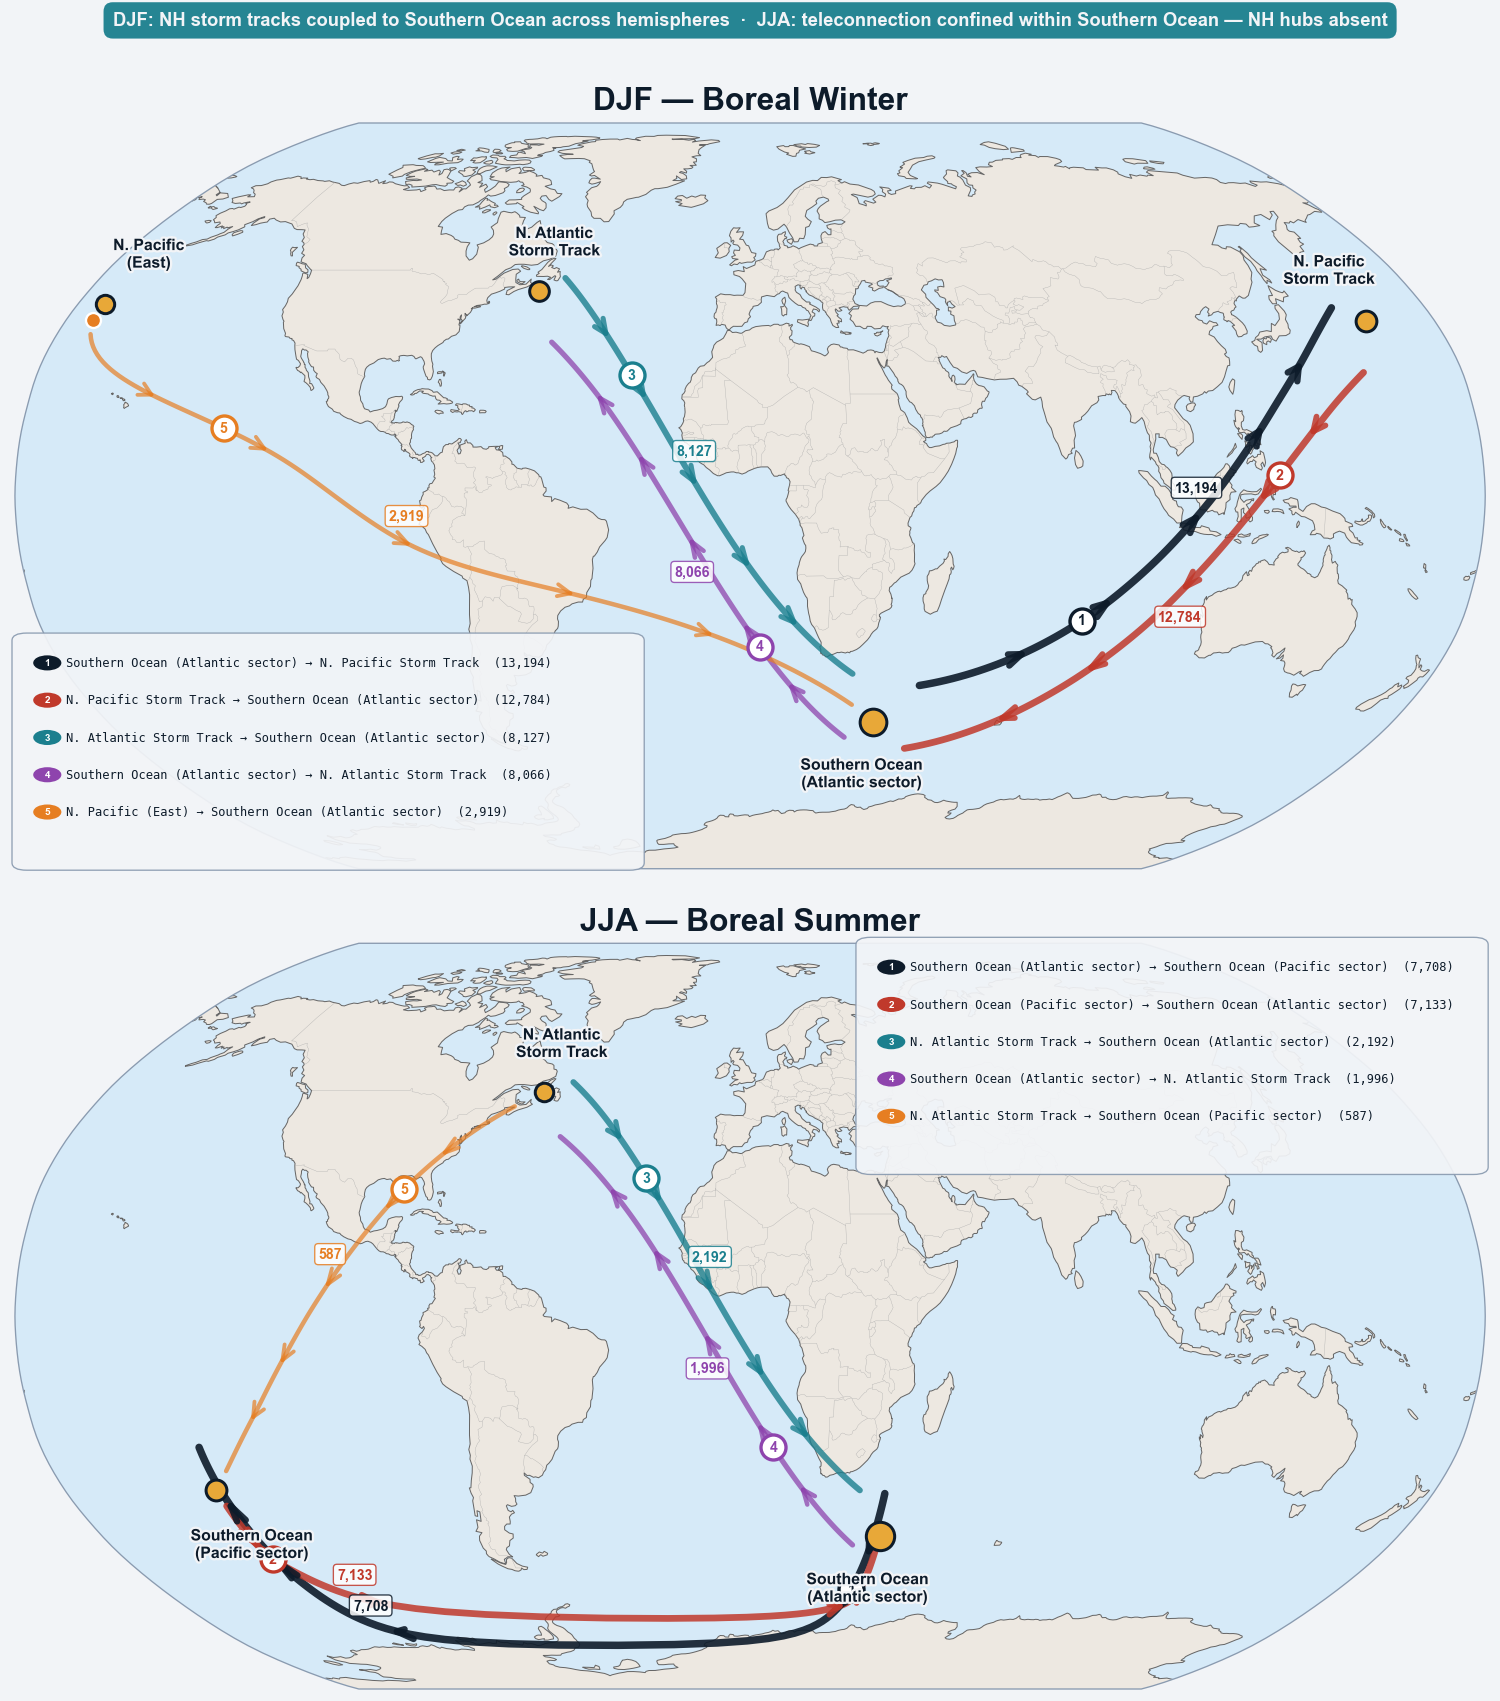

Saved → C:\Users\erenk\OneDrive\Masaüstü\TeleShift\figures\poster\fig5_teleconnection_arrows.png


In [58]:
# ── FIGURE 5 final v5 — waypointed orange arc ──────────────────────────────────
from scipy.interpolate import CubicSpline
import numpy as np

def great_circle_arc_offset(lon1, lat1, lon2, lat2,
                             n_points=120, offset=0.0, hump=0.0,
                             force_direction=None):
    lon1r = np.radians(lon1); lat1r = np.radians(lat1)
    lon2r = np.radians(lon2); lat2r = np.radians(lat2)

    v1 = np.array([np.cos(lat1r)*np.cos(lon1r),
                   np.cos(lat1r)*np.sin(lon1r),
                   np.sin(lat1r)])

    lon2_adj = lon2
    if force_direction == 'eastward' and lon2 <= lon1:
        lon2_adj = lon2 + 360
    elif force_direction == 'westward' and lon2 >= lon1:
        lon2_adj = lon2 - 360

    lon2r_adj = np.radians(lon2_adj)
    v2 = np.array([np.cos(lat2r)*np.cos(lon2r_adj),
                   np.cos(lat2r)*np.sin(lon2r_adj),
                   np.sin(lat2r)])

    dot   = np.clip(np.dot(v1, v2), -1, 1)
    omega = np.arccos(dot)

    lons = []
    lats = []

    if omega < 1e-6:
        lons = [lon1] * n_points
        lats = [lat1] * n_points
    else:
        for t in np.linspace(0, 1, n_points):
            v = (np.sin((1-t)*omega)*v1 + np.sin(t*omega)*v2) / np.sin(omega)
            v = v / np.linalg.norm(v)
            lats.append(np.degrees(np.arcsin(np.clip(v[2], -1, 1))))
            lons.append(np.degrees(np.arctan2(v[1], v[0])))

    lons = np.array(lons)
    lats = np.array(lats) + offset

    if hump != 0.0:
        x    = np.linspace(-1, 1, n_points)
        bell = np.exp(-3.5 * x**2)
        lats = lats + hump * bell

    return lons, lats

def split_antimeridian(lons, lats):
    segments = []
    seg_lons = [lons[0]]
    seg_lats = [lats[0]]
    for i in range(1, len(lons)):
        if abs(lons[i] - lons[i-1]) > 180:
            segments.append((np.array(seg_lons), np.array(seg_lats)))
            seg_lons = [lons[i]]
            seg_lats = [lats[i]]
        else:
            seg_lons.append(lons[i])
            seg_lats.append(lats[i])
    segments.append((np.array(seg_lons), np.array(seg_lats)))
    return segments

def draw_arrowheads(ax, lons, lats, color, lw, alpha, transform):
    n        = len(lons)
    head_len = 3.5
    head_ang = np.radians(22)
    for frac in [0.15, 0.30, 0.50, 0.70, 0.85]:
        idx = max(4, min(int(frac * n), n - 5))
        ex, ey = lons[idx], lats[idx]
        dx = lons[min(idx+3, n-1)] - lons[max(idx-3, 0)]
        dy = lats[min(idx+3, n-1)] - lats[max(idx-3, 0)]
        if abs(dx) > 100:
            dx = -dx
        norm = np.sqrt(dx**2 + dy**2) + 1e-9
        dx /= norm; dy /= norm
        for sign in [-1, +1]:
            cos_a = np.cos(sign * head_ang)
            sin_a = np.sin(sign * head_ang)
            bx = dx*cos_a - dy*sin_a
            by = dx*sin_a + dy*cos_a
            ax.plot([ex, ex - bx*head_len],
                    [ey, ey - by*head_len],
                    transform=transform,
                    color=color, linewidth=lw*0.85,
                    alpha=alpha, solid_capstyle='round', zorder=6)

def draw_arc(ax, lon1, lat1, lon2, lat2,
             color, lw, alpha, label_num,
             edge_count, transform,
             offset=0.0, hump=0.0, label_frac=0.50,
             trim=6, force_direction=None,
             anchor_source=False):

    lons_full, lats_full = great_circle_arc_offset(
        lon1, lat1, lon2, lat2,
        offset=offset, hump=hump,
        force_direction=force_direction)

    if anchor_source:
        ax.plot(lon1, lat1, transform=transform,
                marker='o', markersize=9,
                color=color, markeredgecolor='white',
                markeredgewidth=1.4, zorder=12)
        ax.plot(lons_full[:trim+2], lats_full[:trim+2],
                transform=transform,
                color=color, linewidth=lw*0.65,
                alpha=alpha, zorder=4, solid_capstyle='round')

    lons = lons_full[trim:-trim]
    lats = lats_full[trim:-trim]
    n    = len(lons)

    for seg_lons, seg_lats in split_antimeridian(lons, lats):
        ax.plot(seg_lons, seg_lats, transform=transform,
                color=color, linewidth=lw, alpha=alpha,
                solid_capstyle='round', zorder=4)

    draw_arrowheads(ax, lons, lats, color, lw, alpha, transform)

    # Edge count label
    idx_mid       = n // 2
    arc_lat_range = lats.max() - lats.min()
    lat_sign      = 1 if (offset + hump*0.5) >= 0 else -1
    if arc_lat_range < 8:
        lat_sign  = 1

    ax.text(lons[idx_mid], lats[idx_mid] + 6.5*lat_sign,
            f'{edge_count:,}',
            transform=transform,
            fontsize=8.5, color=color, fontweight='bold',
            ha='center', va='center', zorder=9,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=color, linewidth=0.8, alpha=0.85))

    # Numbered circle at 25%
    idx_circ = int(0.25 * n)
    ax.plot(lons[idx_circ], lats[idx_circ], transform=transform,
            marker='o', markersize=15, color='white', zorder=9,
            markeredgecolor=color, markeredgewidth=2.0)
    ax.text(lons[idx_circ], lats[idx_circ], str(label_num),
            transform=transform, fontsize=8.5, fontweight='bold',
            color=color, ha='center', va='center', zorder=10)

def draw_waypoint_arc(ax, waypoints_lon, waypoints_lat,
                      color, lw, alpha, label_num,
                      edge_count, transform, n_points=120):
    """Draw a smooth arc through manual waypoints using cubic spline."""
    t_wp   = np.linspace(0, 1, len(waypoints_lon))
    t_fine = np.linspace(0, 1, n_points)
    lons   = CubicSpline(t_wp, waypoints_lon)(t_fine)
    lats   = CubicSpline(t_wp, waypoints_lat)(t_fine)

    # Trim 3 points from each end
    lons = lons[3:-3]; lats = lats[3:-3]
    n    = len(lons)

    # Anchor dot at true source
    ax.plot(waypoints_lon[0], waypoints_lat[0],
            transform=transform,
            marker='o', markersize=9,
            color=color, markeredgecolor='white',
            markeredgewidth=1.4, zorder=12)

    ax.plot(lons, lats, transform=transform,
            color=color, linewidth=lw, alpha=alpha,
            solid_capstyle='round', zorder=4)

    draw_arrowheads(ax, lons, lats, color, lw, alpha, transform)

    # Edge count at midpoint
    idx_mid = n // 2
    ax.text(lons[idx_mid], lats[idx_mid] + 6,
            f'{edge_count:,}',
            transform=transform,
            fontsize=8.5, color=color, fontweight='bold',
            ha='center', va='center', zorder=9,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=color, linewidth=0.8, alpha=0.85))

    # Numbered circle at 25%
    idx_circ = int(0.25 * n)
    ax.plot(lons[idx_circ], lats[idx_circ], transform=transform,
            marker='o', markersize=15, color='white', zorder=9,
            markeredgecolor=color, markeredgewidth=2.0)
    ax.text(lons[idx_circ], lats[idx_circ], str(label_num),
            transform=transform, fontsize=8.5, fontweight='bold',
            color=color, ha='center', va='center', zorder=10)

# ── Config ─────────────────────────────────────────────────────────────────────
FLOW_COLORS = ['#0D1B2A', '#C0392B', '#1B7F8E', '#8E44AD', '#E67E22']

REGION_NAMES_DJF = {
    3: 'Southern Ocean\n(Atlantic sector)',
    1: 'N. Pacific\nStorm Track',
    0: 'N. Atlantic\nStorm Track',
    2: 'N. Pacific\n(East)',
    4: 'S. Ocean\n(Pacific sector)',
}
REGION_NAMES_JJA = {
    2: 'Southern Ocean\n(Atlantic sector)',
    1: 'Southern Ocean\n(Pacific sector)',
    0: 'N. Atlantic\nStorm Track',
}

# (offset, hump, force_direction, trim, anchor_source)
DJF_ARCS = [(+7,  0,  None,       6, False),
            (-7,  0,  None,       6, False),
            (+7,  0,  None,       6, False),
            (-7,  0,  None,       6, False),
            ( 0,  0,  'eastward', 2, True )]   # overridden by waypoint logic

JJA_ARCS = [(+14,  0, 'westward', 6, False),
            (  0, 22, 'westward', 6, False),
            ( +6,  0,  None,      6, False),
            ( -6,  0,  None,      6, False),
            (  0,  0,  None,      6, False)]

# Bend southward through Central America and tropical Atlantic
WAYPOINTS_LON = [-173, -150, -115, -85, -50, -10,  35]
WAYPOINTS_LAT = [  38,   22,    8,  -10,  -20, -30, -49]

PROJ = ccrs.Robinson()
PC   = ccrs.PlateCarree()

fig = plt.figure(figsize=(18, 15), facecolor=COLORS['background'])
gs  = gridspec.GridSpec(2, 1, figure=fig,
                        hspace=0.10, top=0.91, bottom=0.04,
                        left=0.01, right=0.99)

ax_DJF = fig.add_subplot(gs[0], projection=PROJ)
ax_JJA = fig.add_subplot(gs[1], projection=PROJ)

season_config = [
    (ax_DJF, 'DJF — Boreal Winter',  summary_DJF,
     top_DJF, REGION_NAMES_DJF, DJF_ARCS, 'bottom_left'),
    (ax_JJA, 'JJA — Boreal Summer',  summary_JJA,
     top_JJA, REGION_NAMES_JJA, JJA_ARCS, 'top_right'),
]

for ax, title, summary, flows, rnames, arc_params, box_pos in season_config:

    ax.set_global()
    ax.add_feature(cfeature.OCEAN,     facecolor='#D6EAF8', zorder=0)
    ax.add_feature(cfeature.LAND,      facecolor='#EDE8E1', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6,
                   edgecolor='#666666', zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.2,
                   edgecolor='#AAAAAA', zorder=2)

    for rank, ((src_cl, tgt_cl, count),
               (offset, hump, fdir, arc_trim, anchor)) in enumerate(
            zip(flows, arc_params)):
        src   = summary[summary['cluster'] == src_cl].iloc[0]
        tgt   = summary[summary['cluster'] == tgt_cl].iloc[0]
        lw    = 4.5 - rank * 0.45
        alpha = 0.90 - rank * 0.05

        # DJF flow 5: waypointed arc across North America
        if src_cl == 2 and tgt_cl == 3 and 'DJF' in title:
            draw_waypoint_arc(
                ax,
                waypoints_lon=WAYPOINTS_LON,
                waypoints_lat=WAYPOINTS_LAT,
                color=FLOW_COLORS[rank],
                lw=lw, alpha=alpha,
                label_num=rank + 1,
                edge_count=count,
                transform=PC
            )
            continue

        draw_arc(ax,
                 src.lon_c, src.lat_c,
                 tgt.lon_c, tgt.lat_c,
                 color=FLOW_COLORS[rank],
                 lw=lw, alpha=alpha,
                 label_num=rank + 1,
                 edge_count=count,
                 transform=PC,
                 offset=offset,
                 hump=hump,
                 force_direction=fdir,
                 trim=arc_trim,
                 anchor_source=anchor)

    # ── Cluster nodes ──────────────────────────────────────────────────────────
    active = set([s for s, t, _ in flows] + [t for s, t, _ in flows])
    for _, row in summary.iterrows():
        if row['cluster'] not in active:
            continue
        ax.scatter(row.lon_c, row.lat_c, transform=PC,
                   s=110 + row['n_nodes'] * 0.45,
                   c=COLORS['hub'],
                   edgecolors=COLORS['text'],
                   linewidths=1.8, zorder=11)
        name    = rnames.get(int(row['cluster']), f'C{int(row["cluster"])}')
        lat_off = -12 if row.lat_c < 0 else 11
        ax.text(row.lon_c, row.lat_c + lat_off, name,
                transform=PC,
                fontsize=9.5, fontweight='bold',
                color=COLORS['text'],
                ha='center', va='center', zorder=12,
                path_effects=[
                    pe.withStroke(linewidth=2.8,
                                  foreground=COLORS['background'])
                ])

    ax.set_title(title, fontsize=19, fontweight='bold',
                 color=COLORS['text'], pad=8)

    # ── Legend box ─────────────────────────────────────────────────────────────
    n_flows = len(flows)
    box_w   = 0.41
    box_h   = 0.038 + n_flows * 0.052
    box_x   = 0.008 if box_pos == 'bottom_left' else 1.0 - box_w - 0.008
    box_y   = (box_h + 0.008) if box_pos == 'bottom_left' else 0.998

    ax.add_patch(mpatches.FancyBboxPatch(
        (box_x, box_y - box_h), box_w, box_h,
        boxstyle='round,pad=0.01',
        transform=ax.transAxes,
        facecolor=COLORS['background'],
        edgecolor=COLORS['caption'],
        linewidth=0.8, alpha=0.93,
        zorder=13, clip_on=False
    ))

    for i, (rank, (src_cl, tgt_cl, count)) in enumerate(enumerate(flows)):
        sn    = rnames.get(src_cl, f'C{src_cl}').replace('\n', ' ')
        tn    = rnames.get(tgt_cl, f'C{tgt_cl}').replace('\n', ' ')
        text  = f'{sn} → {tn}  ({count:,})'
        y_pos = box_y - 0.030 - i * 0.050

        circ = plt.Circle(
            (box_x + 0.014, y_pos), 0.009,
            transform=ax.transAxes,
            color=FLOW_COLORS[rank], zorder=14, clip_on=False
        )
        ax.add_patch(circ)
        ax.text(box_x + 0.014, y_pos, str(rank + 1),
                transform=ax.transAxes,
                fontsize=6, fontweight='bold',
                color='white', ha='center', va='center',
                zorder=15, clip_on=False)
        ax.text(box_x + 0.027, y_pos, text,
                transform=ax.transAxes,
                fontsize=7.2, color=COLORS['text'],
                va='center', zorder=14,
                fontfamily='monospace', clip_on=False)

# ── Header ─────────────────────────────────────────────────────────────────────
fig.text(
    0.5, 0.972,
    'DJF: NH storm tracks coupled to Southern Ocean across hemispheres  ·  '
    'JJA: teleconnection confined within Southern Ocean — NH hubs absent',
    ha='center', va='top',
    fontsize=11, fontweight='bold',
    color=COLORS['background'],
    bbox=dict(boxstyle='round,pad=0.5',
              facecolor=COLORS['threshold'],
              edgecolor='none', alpha=0.95)
)

out_path = os.path.join(FIG_OUT, 'fig5_teleconnection_arrows.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight',
            facecolor=COLORS['background'])
plt.show()
print(f'Saved → {out_path}')

In [55]:
# ── Section 7: Final output verification ──────────────────────────────────────
import os
from PIL import Image

figures = {
    'fig1_hero_hub_maps.png'       : 'Hero — Column 2, large panel',
    'fig2_hub_latitude_bars.png'   : 'Column 2 — below hero',
    'fig3_h1_permutation.png'      : 'Column 1 — H1 stat support',
    'fig4_h3_distances.png'        : 'Column 3 — H3 support',
    'fig5_teleconnection_arrows.png': 'Column 3 — bonus teleconnection figure',
    'fig6_methods_domain.png'      : 'Column 1 — Methods small figure',
}

print(f'{"Figure":<40} {"Size (px)":<20} {"DPI":<8} {"Poster role"}')
print('-' * 100)

all_ok = True
for fname, role in figures.items():
    fpath = os.path.join(FIG_OUT, fname)
    if os.path.exists(fpath):
        img  = Image.open(fpath)
        dpi  = img.info.get('dpi', ('?', '?'))[0]
        size = f'{img.size[0]}×{img.size[1]}'
        status = '✓' if str(dpi) == '300' or int(dpi) >= 300 else '⚠ CHECK DPI'
        print(f'{fname:<40} {size:<20} {str(dpi):<8} {role}')
    else:
        print(f'{fname:<40} {"NOT FOUND":<20} {"—":<8} {role}')
        all_ok = False

print()
if all_ok:
    print('All figures present. Notebook 04 complete.')
    print('Next step: poster assembly + abstract writing.')
else:
    print('Some figures missing — rerun relevant sections.')

Figure                                   Size (px)            DPI      Poster role
----------------------------------------------------------------------------------------------------
fig1_hero_hub_maps.png                   5636×1758            299.9994 Hero — Column 2, large panel
fig2_hub_latitude_bars.png               2557×1721            299.9994 Column 2 — below hero
fig3_h1_permutation.png                  2652×1455            299.9994 Column 1 — H1 stat support
fig4_h3_distances.png                    3853×1535            299.9994 Column 3 — H3 support
fig5_teleconnection_arrows.png           3750×4253            299.9994 Column 3 — bonus teleconnection figure
fig6_methods_domain.png                  3880×1951            299.9994 Column 1 — Methods small figure

All figures present. Notebook 04 complete.
Next step: poster assembly + abstract writing.
